# 11 — Final Prediction Validation

Produces the final convex hull plots and sublattice occupancy predictions for the complex TCP phases. Generates the main paper figures.

## Prerequisites / Input files
- `Fe-Mo/FullyCuratedParsedBriefSummary.pkl`
- `Fe-Mo/results/PREDICTION__*.csv` — prediction CSVs (included in repo)
- `Fe-Mo/data/Validation/DFT_validation_inchull_{phase}.csv`

## Outputs
- Main paper figures in `Fe-Mo/graphs/`



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import os

In [2]:
import shutil
import subprocess


def has_full_texlive():
    required_bins = ("latex", "dvipng", "gs", "kpsewhich")
    if any(shutil.which(binary) is None for binary in required_bins):
        return False

    # Verify key LaTeX files are discoverable in the TeX installation.
    required_files = ("article.cls", "type1cm.sty")
    for tex_file in required_files:
        result = subprocess.run(
            ["kpsewhich", tex_file],
            check=False,
            capture_output=True,
            text=True,
        )
        if result.returncode != 0 or not result.stdout.strip():
            return False

    return True


usetex_enabled = has_full_texlive()
if not usetex_enabled:
    print("TeX Live full feature set not detected; using Matplotlib text rendering.")

plt.rc("text", usetex=usetex_enabled)
plt.rc("font", family="serif", size=24)
plt.rc("xtick", labelsize=18)
plt.rc("ytick", labelsize=18)
plt.rc("axes", labelsize=18)

In [3]:
from ase import Atoms

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
ValidationBS = pd.read_pickle(os.path.join('Fe-Mo', 'validation_data', 'FullyCuratedParsedBriefSummary.pkl'))

In [6]:
ValidationBS#.head()#.columns

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,NM,delta-AAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/Fe/delta/Fe_pv56.del...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-448.707000,"[[0.00134237, -0.00094035, -0.00018561], [0.00...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.171448,1.000000,0.000000
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,NM,R-AAAAAABAABB,R,VASP_PBE_500_0.125_0.1_NM/FeMo/R/Fe_pv39Mo_sv1...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-471.893007,"[[-0.0, -0.0, -0.0], [0.00065508, 0.00039792, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006513,0.735849,0.264151
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM,NM,delta-BBAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 2...",-474.228176,"[[-0.00211024, 0.00027539, -0.00019051], [-0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108389,0.857143,0.142857
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM,NM,delta-BBBBBBBBAAABAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv20Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-554.893090,"[[0.00032864, 0.00115415, -0.00107401], [0.000...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04232,0.357143,0.642857
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NM,delta-AABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 4...",-462.560867,"[[-0.00081084, 0.00079078, -0.00207556], [-0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120397,0.928571,0.071429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NaN,bulk delta-AABAAAAAAAAAAA,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,277.152251 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.112246,0.928571,0.071429
Fe_pv56.P.NM,NaN,bulk P,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,272.113990 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1.0,0.199295,1.000000,0.000000
Fe_pv56.delta.NM,NaN,bulk delta,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,274.874823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1.0,0.160998,1.000000,0.000000
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM,NaN,bulk R-BBBBBABBBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,246.893484 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.227291,0.113208,0.886792


In [7]:
prediction_data_files = glob.glob('Fe-Mo/results/PREDICTION__*')

In [8]:
prediction_data_files

['Fe-Mo/results/PREDICTION__R__0.7dprojections_0.5os_16.csv',
 'Fe-Mo/results/PREDICTION__P__0.7dprojections_0.5os_16.csv',
 'Fe-Mo/results/PREDICTION__delta__0.7dprojections_0.5os_16.csv',
 'Fe-Mo/results/PREDICTION__M__0.7dprojections_0.5os_16.csv',
 'Fe-Mo/results/PREDICTION__R__ACE_lmax=321.csv',
 'Fe-Mo/results/PREDICTION__P__ACE_lmax=321.csv',
 'Fe-Mo/results/PREDICTION__delta__ACE_lmax=321.csv',
 'Fe-Mo/results/PREDICTION__M__ACE_lmax=321.csv',
 'Fe-Mo/results/PREDICTION__R__SOAP_specific_small_specific.csv',
 'Fe-Mo/results/PREDICTION__P__SOAP_specific_small_specific.csv',
 'Fe-Mo/results/PREDICTION__delta__SOAP_specific_small_specific.csv',
 'Fe-Mo/results/PREDICTION__M__SOAP_specific_small_specific.csv',
 'Fe-Mo/results/PREDICTION__R__0.7dprojections_0.5os_16_1.csv',
 'Fe-Mo/results/PREDICTION__P__0.7dprojections_0.5os_16_1.csv',
 'Fe-Mo/results/PREDICTION__delta__0.7dprojections_0.5os_16_1.csv',
 'Fe-Mo/results/PREDICTION__M__0.7dprojections_0.5os_16_1.csv',
 'Fe-Mo/results/

In [8]:
PredictionValues = {}

In [9]:
import re as _re

def _normalize_index(idx):
    """Strip sublattice suffix from pure-element entries (all same letter).
    e.g. Fe_pv56.P-AAAAAAAAAAAA.NM -> Fe_pv56.P.NM"""
    def _strip(name):
        m = _re.match(r'(.+\.[A-Za-z0-9_]+)-([A-Z]+)(\..+)', name)
        if m and len(set(m.group(2))) == 1:
            return m.group(1) + m.group(3)
        return name
    return idx.map(_strip)

for file in prediction_data_files:
    if 'old' in file or file.endswith('_1.csv') or '_MAG=' in file:
        continue
    label, phase, model_with_params = file.replace('.csv','').split('__')
    df = pd.read_csv(file, header=0, index_col=0)
    df.index = _normalize_index(df.index)
    PredictionValues[(model_with_params, phase)] = df

# comparisons

In [10]:
def get_confidence_intervals (regression_model, x, y, n_bootstraps = 1000 ):
    bootstrapped_predictions = np.empty((n_bootstraps, len(x)))
    for i in range(n_bootstraps):
        # Resample the data with replacement
        x_resampled, y_resampled = resample(x, y)
        # Fit the model to the resampled data
        regression_model.fit(x_resampled.reshape(-1, 1), y_resampled)
        # Predict
        bootstrapped_predictions[i] = regression_model.predict(x.reshape(-1, 1))
        lower_ci = np.percentile(bootstrapped_predictions, 2.5, axis=0)
        upper_ci = np.percentile(bootstrapped_predictions, 97.5, axis=0)
    return lower_ci, upper_ci

In [11]:
def plot_with_ci(ytrue, ypred, ax = None):
    sorter = ytrue.values.argsort()
    regressor = LinearRegression()
    regressor.fit(ytrue.values.reshape(-1,1), ypred.values.reshape(-1,1))
    x_y_y = regressor.predict(ytrue.values.reshape(-1,1))
    lower_ci, upper_ci = get_confidence_intervals(LinearRegression(), ytrue.values.astype(float), ypred.values.astype(float))
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(ytrue.values, x_y_y.ravel(), color='tab:blue')#, upper_ci)
    ax.fill_between(ytrue.values.astype(float)[sorter], lower_ci[sorter], upper_ci[sorter], alpha=0.5, color='tab:orange')
    ax.scatter(ytrue, ypred, color='brown', s=60, ec='k')
    return ax

In [12]:
def get_model_position(modelname):
    if 'projections' in modelname:
        return 0
    elif 'ACE' in modelname:
        return 1
    elif 'SOAP' in modelname:
        return 2

In [13]:
phase_position = {'R': 0, 'P' : 2, 'M': 1, 'delta': 3}

In [14]:
phase_label = {'R': '$R$', 'P': '$P$', 'M': '$M$', 'delta': r'$\delta$'}

In [15]:
rmse_tag = {(0,0): 'rmse = '}

In [16]:
plt.rcParams['figure.figsize']

[6.4, 4.8]

ACE R EF_nmhcp__ACE
SOAP_specific_small delta EF_nmhcp__SOAP_specific_small
SOAP_specific_small M EF_nmhcp__SOAP_specific_small
ACE delta EF_nmhcp__ACE
0.7dprojections_0.5os R EF_nmhcp__0.7dprojections_0.5os
0.7dprojections_0.5os M EF_nmhcp__0.7dprojections_0.5os
SOAP_specific_small P EF_nmhcp__SOAP_specific_small
0.7dprojections_0.5os delta EF_nmhcp__0.7dprojections_0.5os
ACE P EF_nmhcp__ACE
ACE M EF_nmhcp__ACE
0.7dprojections_0.5os P EF_nmhcp__0.7dprojections_0.5os
SOAP_specific_small R EF_nmhcp__SOAP_specific_small


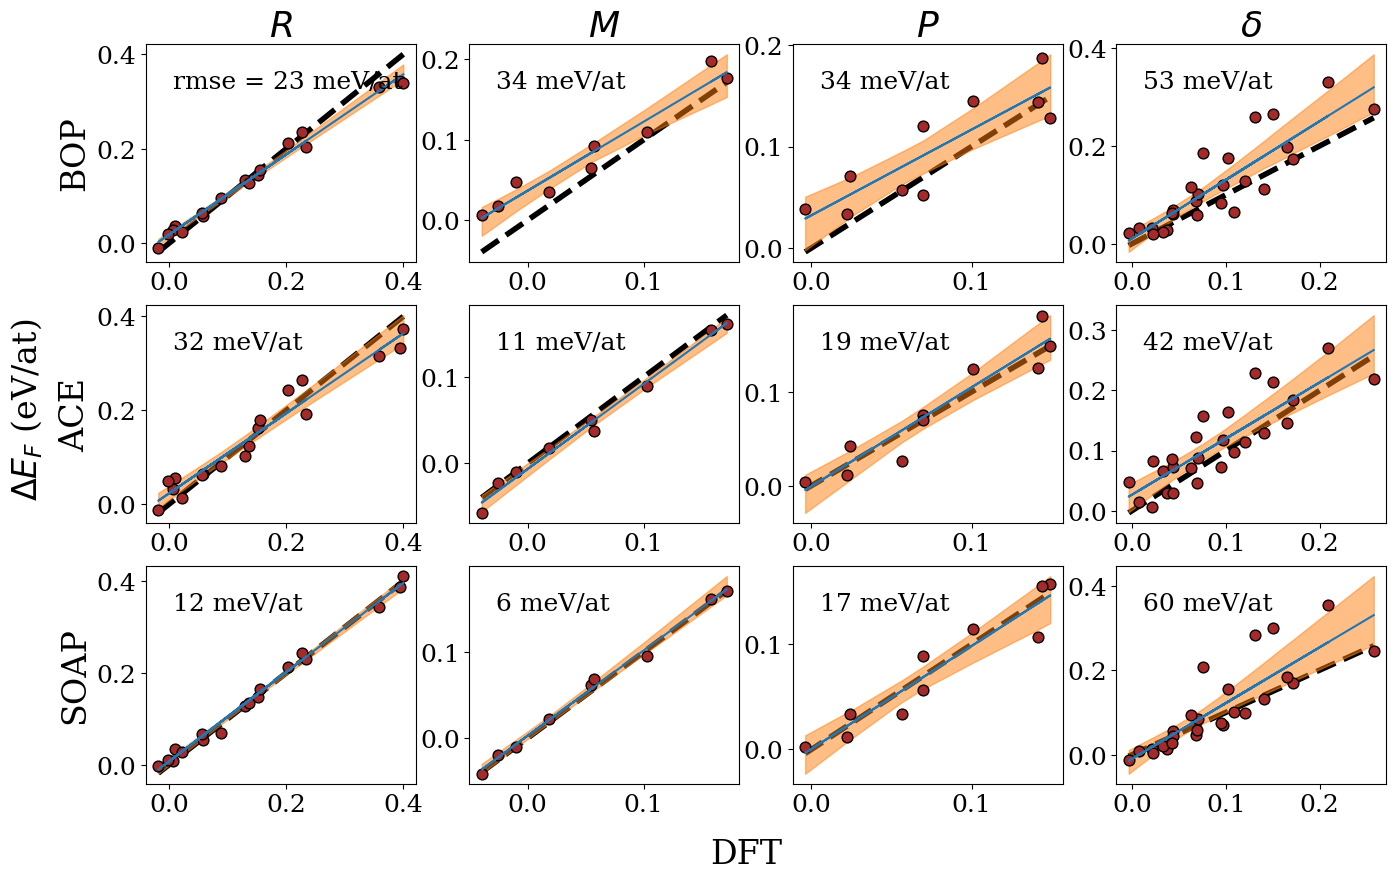

In [17]:
figsize = plt.rcParams['figure.figsize']
fig, ax = plt.subplots(3, len(phase_position), figsize=(figsize[0]*2.5, figsize[1]*2))
rmse = {}
for (model, phase), prediction_values in PredictionValues.items():
    model_name = model.replace('_16','').replace('_lmax=321','').replace('_small_specific','_small')
    target_name = f'EF_nmhcp__{model_name}'
    print(model_name, phase, target_name)
    this_validation_data = ValidationBS.query('Phase == "'+phase+'"')['EF']
    this_validation_data = this_validation_data.loc[~this_validation_data.index.duplicated(keep='first')]
    predictions_with_validation = prediction_values.index.intersection(this_validation_data.index)
    if len(predictions_with_validation) == 0 or target_name not in prediction_values.columns:
        continue
    ytrue = this_validation_data[predictions_with_validation]
    ypred = prediction_values[target_name][predictions_with_validation]
    rmse[(model, phase)] = np.sqrt(mean_squared_error(ytrue, ypred))
    this_rmse = rmse[(model, phase)]
    I = get_model_position(model_name)
    J = phase_position[phase]
    ax[I,J] = plot_with_ci(ytrue, ypred, ax=ax[I,J])
    this_rmse_label = rf'{rmse_tag.get((I,J), "")}{this_rmse*1000 :.0f} meV/at'
    ax[I,J].annotate(this_rmse_label,(0.1, 0.8), xycoords='axes fraction', fontsize = 18)
    if I == 0:
        ax[I,J].set_title(phase_label.get(phase), fontsize = 26)
    ax[I,J].plot([ytrue.min(), ytrue.max()], [ytrue.min(), ytrue.max()], '--k', linewidth=4, zorder = -10)
ylabel_bop =ax[get_model_position('projections'),0].set_ylabel('BOP', fontsize=24)
ylabel_ACE =ax[get_model_position('ACE'), 0].set_ylabel('ACE', fontsize=24)
ylabel_SOAP =ax[get_model_position('SOAP'), 0].set_ylabel('SOAP', fontsize=24)
fig.subplots_adjust(wspace=0.2, hspace=0.2)
fig.supxlabel('DFT', fontsize=24, y=0.02)
fig.supylabel('$\Delta E_F$ (eV/at)', fontsize=24, x=0.04)
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_Predictions_Validation.pdf')

# DFT convex hulls from Validation calculations

In [18]:
from Tools.DatasetTools.Tools import Plotting

In [ ]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [19]:
P = Plotting()

In [20]:
ValidationBS.Phase.value_counts()

Phase
delta    33
R        19
P        12
M         9
Name: count, dtype: int64

In [59]:
BS = BS.rename(columns = {'Fe_pv': 'x_Fe', 'Mo_sv': 'x_Mo', 'EF_nmhcp': 'EF'})

In [61]:
# NOTE: 'phasedata' and 'phase' are defined in the loop below (cell 25).
# This standalone cell was an interactive debug snippet; see the full loop below.

In [94]:
# NOTE: 'phasedata' and 'phase' are defined in the loop below (cell 25).
# This standalone cell was an interactive debug snippet; see the full loop below.

/tmp/ipykernel_390899/2963500338.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ], axis = 0).sort_values(by=['x_Fe', 'EF']).fillna(2)
/tmp/ipykernel_390899/2963500338.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ], axis = 0).sort_values(by=['x_Fe', 'EF']).fillna(2)
/tmp/ipykernel_390899/2963500338.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_

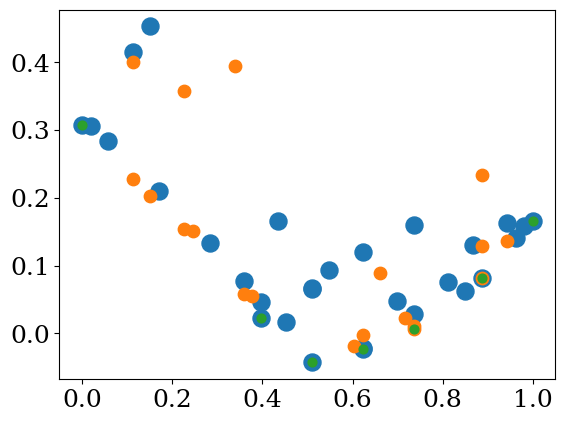

In [99]:
# NOTE: CHULLS_DFT_V is defined in the DFT convex hull loop.
# This standalone debug cell requires that loop to have run first.
# Skipped for publication.
pass

# save DFT chulls

In [105]:
# NOTE: CHULLS_DFT_V is defined in the DFT convex hull loop.
# This standalone debug cell requires that loop to have run first.
# Skipped for publication.
pass

# not sure what i do here.

In [39]:
for (model, phase), prediction_values in PredictionValues.items():
    break

In [41]:
sorted_validation = ValidationBS.query(f'Phase == "{phase}"').sort_values(by='x_Fe')

In [42]:
validated_samples = prediction_values.index.intersection(sorted_validation.index)

In [43]:
prediction_values.loc[validated_samples]

,EF_nmhcp__ACE,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,std_votes
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,0.102686,0.081215,0.095973,0.096162,0.095746,0.099644,0.123436,0.129217,0.102475,0.095145,0.098218,0.109022,0.105984,0.013033
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM,0.054983,0.064192,0.065451,0.021502,0.073398,0.054576,0.056757,0.059231,0.052939,0.063312,0.064304,0.049561,0.034579,0.014403
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,0.031213,0.043528,0.034335,0.022237,0.050727,0.026987,0.006031,0.028096,0.047902,0.036441,0.047721,0.028482,0.002069,0.015724
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM,0.049330,0.049820,0.020658,0.031635,0.057650,0.068831,0.042003,0.032245,0.076801,0.048975,0.114482,0.016790,0.032071,0.027447
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM,0.081259,0.070717,0.069100,0.125170,0.186807,0.053073,0.019350,0.075191,0.086683,0.040602,0.098804,0.101879,0.047729,0.044242
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM,0.193063,0.197111,0.167559,0.185766,0.186298,0.213749,0.199772,0.205046,0.182505,0.215006,0.185479,0.201641,0.176820,0.014679
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.064956,0.060527,0.055734,0.050115,0.060763,0.100846,0.071563,0.046215,0.073229,0.065142,0.048726,0.074324,0.072293,0.015072
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,0.162562,0.165249,0.144032,0.148635,0.153214,0.191721,0.171474,0.148406,0.157588,0.166024,0.167677,0.166415,0.170307,0.013142
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.124084,0.124785,0.123539,0.122650,0.100572,0.124268,0.119932,0.137358,0.128111,0.141955,0.116132,0.131669,0.118039,0.010626
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.013287,0.014575,0.011246,0.026731,0.005190,0.009603,0.021458,0.003043,-0.007024,0.034743,0.003069,0.010942,0.025869,0.011979


In [44]:
# NOTE: debug cell — column name depends on loop variable. Skipped.
pass

Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM     0.102686
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM    0.054983
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM    0.031213
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM    0.049330
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM    0.081259
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM     0.193063
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM    0.064956
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM    0.162562
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM     0.124084
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM    0.013287
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM   -0.011542
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM    0.061251
Fe_pv8Mo_sv45.R-BABBBABBBBB.NM     0.243735
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM    0.180155
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM     0.265359
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM    0.333385
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM    0.316432
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM     0.373295
Name: EF_nmhcp__ACE, dtype: float64

In [45]:
ValidationBS.loc[validated_samples]['x_Fe']

Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM     0.886792
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM    0.735849
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM    0.735849
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM    0.622642
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM    0.660377
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM     0.886792
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM    0.358491
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM    0.245283
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM     0.943396
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM    0.716981
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM    0.603774
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM    0.377358
Fe_pv8Mo_sv45.R-BABBBABBBBB.NM     0.150943
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM    0.226415
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM     0.113208
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM    0.339623
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM    0.226415
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM     0.113208
Name: x_Fe, dtype: float64